In [1]:
%pip install tensorflow


  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/7d/0d/4ee4bc074597b41c9c00dc97b4418ef1eb8736fe9186ffdb3961efdfb730/tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/18/a6/907a406bb7d359e6a63f99c313846d9eec4f7e6f7437809e03aa00fa3074/absl_py-2.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=25.9.23 from https://files.pythonhosted.org/packages/e8/2d/d2a548598be01649e2d46231d151a6c56d10b964d94043a335ae56ea2d92/flatbuffers-25.12.19-py2.py3-none-any.whl.metadata
  Obtaining dependency information for gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 from https://files.pythonhosted.org/packages/1d/33/f1c6a276de27b7

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📘 07-1 인공신경망 (패션 MNIST) (1)

1. 학습 시작
2. loss 확인
3. train vs validation 비교
4. 과적합 체크
5. dropout으로 조정
6. EarlyStopping으로 멈춤
7. best 모델 저장

In [14]:
from tensorflow.keras.datasets import fashion_mnist
(train_input, train_target),(test_input,test_target)=fashion_mnist.load_data()

In [16]:
data=fashion_mnist.load_data()
type(data)

tuple

In [ ]:
type(fashion_mnist.load_data())

tuple

In [26]:
type(train_input)

numpy.ndarray

In [ ]:
len(data)
#두 덩어리=train/test 라는 것은 이미 트레인과 테스트로 나누어 줬다는 의미 

2

In [ ]:
#이미train/test 나뉜 데이터(교육용, 유명데이터
#fashion_mnist.load_data()
#cifar10.load_data()
#imdb.load_data()

In [4]:
type(train_input)

numpy.ndarray

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
#다 나뉘어져 있어서 나위어져 있는걸 가져다 씀 
(train_input, train_target), (test_input, test_target) = fashion_mnist.load_data()

print("훈련 레이블 모양:", train_target.shape)          # (60000,)
print("유일한 클래스 값들:", np.unique(train_target))   # [0 1 2 3 4 5 6 7 8 9]
print("클래스 개수:", len(np.unique(train_target)))     # 10


훈련 레이블 모양: (60000,)
유일한 클래스 값들: [0 1 2 3 4 5 6 7 8 9]
클래스 개수: 10


In [23]:
# 훈련데이터는 60,000개의 이미지로 이루어져 있다. 각 이미지의 크기는 28*28이다.
#타깃데이터는 60,000개의 원소로 이루어진 1차원 배열이다. 

In [21]:
train_input.shape, train_target.shape, test_input.shape, test_target.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

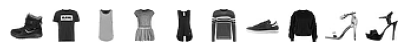

In [85]:
import matplotlib.pyplot as plt
fix,axs=plt.subplots(1,10,figsize=(5,5))
for  i in range(10):
    axs[i].imshow(train_input[i],cmap='gray_r')
    axs[i].axis('off')
    
plt.show()


In [44]:
#레이블  : 0 티셔츠, 1 바지, 2 스웨터, 3 드레스, 4 코트, 5 샌달, 6셔츠, 7 스니커즈, 8 가방, 9 앵글 부츠

In [42]:
[int(train_target[i])for i in range(10)]

[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]

In [51]:
#넘파이로 해당 레이블당 셈플의 개수를 확인해 보자
print(np.unique(train_target, return_counts=True))
print(np.unique(train_target))
print(len(np.unique(train_target)))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))
[0 1 2 3 4 5 6 7 8 9]
10


# 🔹 3. SGD를 이용한 로지스틱 회귀로 패션 아이템 분류하기

In [56]:
#정규화, 패션mnist의 경우 각 필셀은 0~255사이의 정수값을 가진다. 
#이런 이미지의 경우 보통 255로 나누어 0-1사이의 값으로 정규화 한다. 
train_scaled=train_input/255

In [57]:
#SGDClassifie(확률적 경사 하강법)는 이미지 형태 2D를 그대로 못쓰고, 1차원벡터로 변환해야 한다. 
train_scaled=train_scaled.reshape(-1,28*28)

In [58]:
train_scaled.shape


(60000, 784)

In [59]:
train_scaled.ndim

2

In [63]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

#max_iter=5반복횟수
sc=SGDClassifier(loss='log_loss', max_iter=100,random_state=42)
scores=cross_validate(sc,train_scaled,train_target)
scores
# print(np.mean(scores['test_score']))

{'fit_time': array([31.0858829 , 31.82388401, 31.36410785, 30.78067398, 31.06292987]),
 'score_time': array([0.02892113, 0.0298934 , 0.02889609, 0.02991652, 0.0289197 ]),
 'test_score': array([0.84716667, 0.84275   , 0.84008333, 0.83583333, 0.83283333])}

In [ ]:
#로지스틱회귀 공식
#z=a*무게+b*길이 + c*대각선+ d*높이+ e*두께  + f
#이것을 엠니스트의 데이터에 맞게 변형하면
#Z_티셔츠=w1*픽셀1+ㅈ2*픽셀2...........w784*픽셀784+절편
#4장의 선형방정식과 동일하며 티셔츠와 바지 모두 가중치와 절편만 다른값을 사용한다. 

# 4.인공신경망

x1 ~ x784까지를 입력층
z1 ~ z10을 계산하고 이를 바탕으로 클래스를 예측하기 때문에 신경망의 최종 값을 만든다는 의미에서 출력층이라고 한다.
인경 신경망에서 z값을 계산하는 단위를 뉴런(또는 유닛)이라고 한다.

# 6.텐서플로& 케라스

In [65]:
from tensorflow import keras

In [67]:
train_scaled.shape, train_target.shape

((60000, 784), (60000,))

In [68]:
#훈련세트에서 20%를 검증세트로 train_test_split()함수를 사용하여 나눈다
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target=train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [70]:
train_scaled.shape, val_scaled.shape, train_target.shape, val_target.shape

((48000, 784), (12000, 784), (48000,), (12000,))

# 신경망 모델 만들기

In [ ]:
#가장기본이 되는 층을 밀집층이라고 한다.
#784*10=7,840개의 선이 연결되어 있다.-> 이런층을 완전 연결층이라고 한다. 

In [76]:
#케라스 Dense클래스를 사용해 밀집층을 만들어 보자
dense=keras.layers.Dense(10,activation='softmax',input_shape=(784,))
#첫번째 매개변수로 뉴런 개수지정 10,10개의 패션 아이템 분류
#두번째 매개변수 : 뉴런의 출력에 적용할 함수,
# 실함수-> activation='softmax'다중분류
#이진분류이면 시그모이드함수 사용(activation='sigmoid')
#세번째 매개변수 : 입력값의 크기, 10개의 뉴런이 각각 몇개를 입력받는지 튜플로 지정한다. 
#여기에서는 784개의 픽셀값을 받음.

In [78]:
#위에서 만든 밀집층을 가진 신경망 모뎅을 만든다.
#케라스의 Sequential클래스를 사용한다. 
model=keras.Sequential([dense])

# ⚙ 8. 모델 컴파일 & 학습

In [ ]:
#compile()메서드를 수행한다.
#여기에서 꼭 지정해야 하는 것이 손실함수의 종류이다.
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#loss손실함수: 이진분류binary_crossentropy
#이진분류는 binary_crossentropy
#다중분류는 categorical_crossentropy -> 정답형태:원-핫 인코딩
#다중분류는 sparse_categorical_crossentropy-> 정답형태: 숫자라벨

#metrics=['accuray']:'정확도(accuracy)'를 평가 지표로 사용하겠다.

In [ ]:
train_scaled.shape, val_scaled.shape, train_target.shape, val_target.shape

In [82]:
#패션MNIST데이터의 타깃값은:
train_target[:10]

array([7, 3, 5, 8, 6, 9, 3, 3, 9, 9], dtype=uint8)

In [ ]:
model.fit(train_scaled,train_target,epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7924 - loss: 0.6074
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8396 - loss: 0.4743
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8471 - loss: 0.4499
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8513 - loss: 0.4383
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8549 - loss: 0.4288


In [ ]:
#케라스는 에포크마다 걸린 시간과 손실(loss), 정확도(accuracy)를 출력해준다.
#batch_size=32
#60000%32=1500 batch